In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit


In [39]:
data = pd.read_csv("BTC-Daily.csv")
# Display the first few rows of the dataset
print(data.head())

         unix                 date   symbol      open      high       low  \
0  1646092800  2022-03-01 00:00:00  BTC/USD  43221.71  43626.49  43185.48   
1  1646006400  2022-02-28 00:00:00  BTC/USD  37717.10  44256.08  37468.99   
2  1645920000  2022-02-27 00:00:00  BTC/USD  39146.66  39886.92  37015.74   
3  1645833600  2022-02-26 00:00:00  BTC/USD  39242.64  40330.99  38600.00   
4  1645747200  2022-02-25 00:00:00  BTC/USD  38360.93  39727.97  38027.61   

      close   Volume BTC    Volume USD  
0  43185.48    49.006289  2.116360e+06  
1  43178.98  3160.618070  1.364723e+08  
2  37712.68  1701.817043  6.418008e+07  
3  39146.66   912.724087  3.573010e+07  
4  39231.64  2202.851827  8.642149e+07  


In [40]:
data['date'] = pd.to_datetime(data['date'])
print("\nDataset Description:")
print(data.describe())



Dataset Description:
               unix          open          high           low         close  \
count  2.651000e+03   2651.000000   2651.000000   2651.000000   2651.000000   
mean   1.531613e+09  11693.189332  12038.562912  11296.539461  11709.326213   
std    6.613247e+07  16272.554746  16739.237000  15718.297511  16282.908704   
min    1.417133e+09    162.000000    212.840000    152.400000    162.000000   
25%    1.474373e+09    654.680000    664.460000    640.050000    654.370000   
50%    1.531613e+09   6408.950000   6540.000000   6312.000000   6407.770000   
75%    1.588853e+09  10708.620000  10956.240000  10303.755000  10726.425000   
max    1.646093e+09  67547.490000  69000.000000  66250.000000  67559.000000   

         Volume BTC    Volume USD  
count  2.651000e+03  2.651000e+03  
mean   1.330041e+07  6.099369e+07  
std    4.715366e+07  1.072838e+08  
min    0.000000e+00  0.000000e+00  
25%    5.357883e+03  9.516170e+03  
50%    1.503310e+04  2.288982e+07  
75%    3.43533

In [41]:
# Check for missing values
print("Missing Values:")
print(data.isnull().sum())

# Check for anomalous data
print("\nAnomalous Data:")
print(data.describe())

Missing Values:
unix          0
date          0
symbol        0
open          0
high          0
low           0
close         0
Volume BTC    0
Volume USD    0
dtype: int64

Anomalous Data:
               unix          open          high           low         close  \
count  2.651000e+03   2651.000000   2651.000000   2651.000000   2651.000000   
mean   1.531613e+09  11693.189332  12038.562912  11296.539461  11709.326213   
std    6.613247e+07  16272.554746  16739.237000  15718.297511  16282.908704   
min    1.417133e+09    162.000000    212.840000    152.400000    162.000000   
25%    1.474373e+09    654.680000    664.460000    640.050000    654.370000   
50%    1.531613e+09   6408.950000   6540.000000   6312.000000   6407.770000   
75%    1.588853e+09  10708.620000  10956.240000  10303.755000  10726.425000   
max    1.646093e+09  67547.490000  69000.000000  66250.000000  67559.000000   

         Volume BTC    Volume USD  
count  2.651000e+03  2.651000e+03  
mean   1.330041e+07  6.099

In [42]:
# Normalizing closing prices
max_price = data['close'].max()
min_price = data['close'].min()
data['normalized_close'] = (data['close'] - min_price) / (max_price - min_price)

print("\nNormalized Closing Prices:")
print(data[['date', 'close', 'normalized_close']].head())


Normalized Closing Prices:
        date     close  normalized_close
0 2022-03-01  43185.48          0.638359
1 2022-02-28  43178.98          0.638263
2 2022-02-27  37712.68          0.557157
3 2022-02-26  39146.66          0.578433
4 2022-02-25  39231.64          0.579694



Range of Dates Covered:
Start Date: 2014-11-28 00:00:00
End Date: 2022-03-01 00:00:00


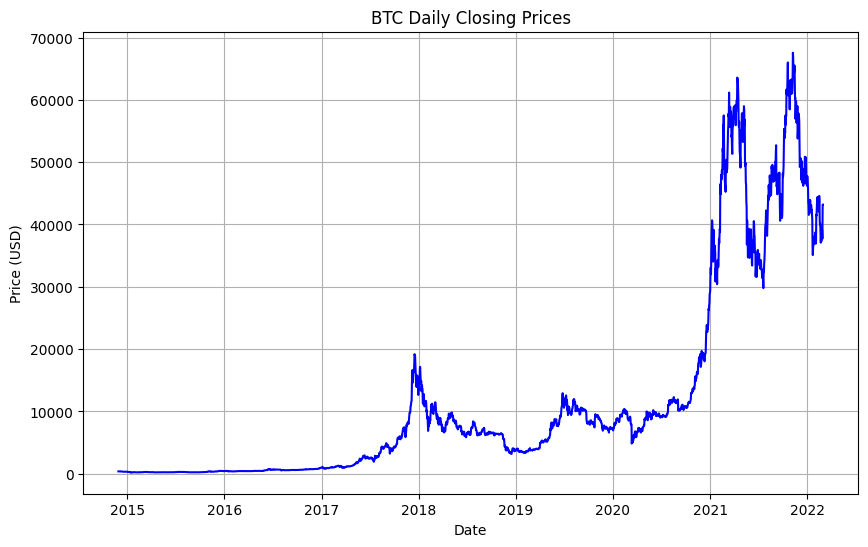

In [43]:

# Range of dates covered
print("\nRange of Dates Covered:")
print("Start Date:", data['date'].min())
print("End Date:", data['date'].max())

# Visualize daily closing prices
plt.figure(figsize=(10, 6))
plt.plot(data['date'], data['close'], color='b')
plt.title('BTC Daily Closing Prices')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()


                                            LINEAR REGRESSION

In [44]:
# Convert dates to Unix timestamps
data['unix_timestamp'] = data['date'].astype(np.int64) // 10**9
print(data.columns)
# Split the data into features (X) and target variable (y)
X = data[['unix_timestamp']]
y = data['close']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict the prices
y_pred = model.predict(X_test)

# Calculate RMSE, MAE, and MAPE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)


Index(['unix', 'date', 'symbol', 'open', 'high', 'low', 'close', 'Volume BTC',
       'Volume USD', 'normalized_close', 'unix_timestamp'],
      dtype='object')
RMSE: 10160.617983034435
MAE: 7857.78411595163
MAPE: 511.48252831791206


Because financial markets are complicated and non-linear, employing a linear model to forecast Bitcoin values based purely on dates as numerical attributes is ineffective. Financial data, especially Bitcoin prices, show temporal patterns, trends, and non-linear correlations that linear models struggle to represent adequately.

                                            POLYNOMIAL REGRESSION
Polynomial regression builds on linear regression by include polynomial elements in the model equation, allowing it to capture non-linear correlations between data and the target variable. Along with this we can see that our data has patterns that a polynomial regression can capture.

In [16]:
# Convert dates to numerical features
data['unix_timestamp'] = data['date'].astype(np.int64) // 10**9

# Split the data into features (X) and target variable (y)
X = data[['unix_timestamp']]
y = data['close']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define polynomial degree
degree = 2  # You can adjust this as needed

# Create polynomial features
poly = PolynomialFeatures(degree=degree)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

# Initialize and fit the polynomial regression model
model = LinearRegression()
model.fit(X_poly_train, y_train)

# Predict the prices
y_pred = model.predict(X_poly_test)

# Calculate RMSE, MAE, and MAPE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

#we can see by the results that polynomial regression is better than linear regression

RMSE: 7444.30841621138
MAE: 5338.777445662997
MAPE: 218.00147011797213


                                                ARIMA

Index(['unix', 'date', 'symbol', 'open', 'high', 'low', 'close', 'Volume BTC',
       'Volume USD', 'normalized_close'],
      dtype='object')
ADF Statistic: -1.9179885007511597
p-value: 0.3236466435035965
Critical Values:
	1%: -3.4328464582522136
	5%: -2.8626429445545245
	10%: -2.5673571362774994
ADF Statistic: -8.529483755605037
p-value: 1.0470896570982091e-13
Critical Values:
	1%: -3.43284741167062
	5%: -2.8626433656018726
	10%: -2.5673573604457642


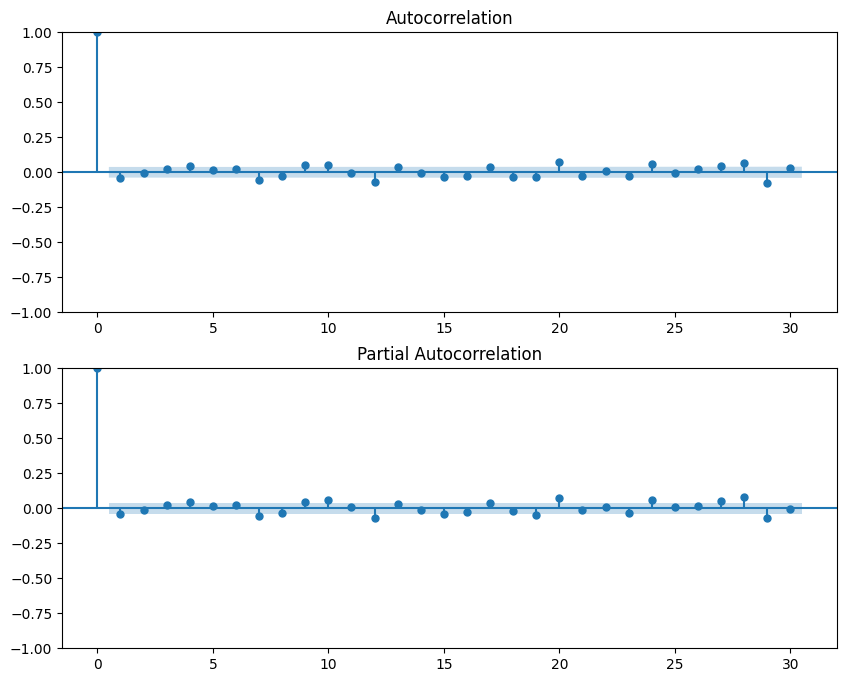

In [45]:

# Set 'unix_timestamp' column as index
data.set_index('unix_timestamp', inplace=True)
print(data.columns)
# Check for stationarity
def test_stationarity(timeseries):
    # Perform Dickey-Fuller test
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t{}: {}'.format(key, value))
    
# Test for stationarity
test_stationarity(data['close'])

# If not stationary, perform differencing
data_diff = data['close'].diff().dropna()
test_stationarity(data_diff)


# Plot ACF and PACF
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(data_diff, ax=ax[0], lags=30)
plot_pacf(data_diff, ax=ax[1], lags=30)
plt.show()


                                        Cross Validation

In [54]:
data.reset_index(inplace=True)

In [55]:

# Set 'date' column as index
data.set_index('unix', inplace=True)

# Define evaluation metrics dictionary
evaluation_metrics = {'RMSE': [], 'MAE': [], 'MAPE': []}

# Define rolling window technique
rolling_window = 30

# Split data into train and test sets using rolling window
for i in range(rolling_window, len(data)):
    data_train = data.iloc[i - rolling_window:i]
    data_test = data.iloc[i:i + 1]  # Predicting one step ahead

    # Linear Regression
    lr_model = LinearRegression()
    lr_model.fit(data_train.index.values.reshape(-1, 1), data_train['close'])
    lr_predictions = lr_model.predict(data_test.index.values.reshape(-1, 1))

    # Polynomial Regression
    poly_features = PolynomialFeatures(degree=2)
    X_poly = poly_features.fit_transform(data_train.index.values.reshape(-1, 1))
    lr_poly_model = LinearRegression()
    lr_poly_model.fit(X_poly, data_train['close'])
    lr_poly_predictions = lr_poly_model.predict(poly_features.fit_transform(data_test.index.values.reshape(-1, 1)))
    
    # Calculate evaluation metrics for linear regression
    rmse_lr = np.sqrt(mean_squared_error(data_test['close'], lr_predictions))
    mae_lr = mean_absolute_error(data_test['close'], lr_predictions)
    mape_lr = np.mean(np.abs((data_test['close'] - lr_predictions) / data_test['close'])) * 100

    # Calculate evaluation metrics for polynomial regression
    rmse_poly = np.sqrt(mean_squared_error(data_test['close'], lr_poly_predictions))
    mae_poly = mean_absolute_error(data_test['close'], lr_poly_predictions)
    mape_poly = np.mean(np.abs((data_test['close'] - lr_poly_predictions) / data_test['close'])) * 100

    # Append to evaluation_metrics dictionary
    evaluation_metrics['RMSE'].append({'LR': rmse_lr, 'Poly': rmse_poly})
    evaluation_metrics['MAE'].append({'LR': mae_lr, 'Poly': mae_poly})
    evaluation_metrics['MAPE'].append({'LR': mape_lr, 'Poly': mape_poly})

# Print evaluation metrics
print("Evaluation Metrics:")
for metric, values in evaluation_metrics.items():
    print(metric)
    for model, metric_values in zip(['LR', 'Poly'], values):
        # Calculate mean for each model
        mean_lr = np.mean(metric_values['LR'])
        mean_poly = np.mean(metric_values['Poly'])
        
        # Print mean for each model
        print(f"\t{model}: LR - {mean_lr}, Poly - {mean_poly}")



Evaluation Metrics:
RMSE
	LR: LR - 3402.745908045974, Poly - 1075.585405044556
	Poly: LR - 2952.8846896551768, Poly - 539.5432981491103
MAE
	LR: LR - 3402.745908045974, Poly - 1075.585405044556
	Poly: LR - 2952.8846896551768, Poly - 539.5432981491103
MAPE
	LR: LR - 8.968325473174387, Poly - 2.83482817915576
	Poly: LR - 7.731552248024625, Poly - 1.4126888240253304


In [67]:
data.set_index('date', inplace=True)
# Ensure date index is sorted in ascending order
data.sort_index(inplace=True)

# Define evaluation metrics dictionary
evaluation_metrics = {'RMSE': [], 'MAE': [], 'MAPE': []}

# Define rolling window technique
rolling_window = 30

# Split data into train and test sets using rolling window
for i in range(rolling_window, len(data)):
    data_train = data.iloc[i - rolling_window:i]
    data_test = data.iloc[i:i + 1]  # Predicting one step ahead

    try:
        # ARIMA model
        arima_model = ARIMA(data_train['close'], order=(5,1,0))
        arima_result = arima_model.fit()
        arima_predictions = arima_result.forecast(steps=1)[0]  # Extract the forecasted value
        
        # Calculate evaluation metrics for ARIMA
        rmse_arima = np.sqrt(mean_squared_error(data_test['close'], arima_predictions))
        mae_arima = mean_absolute_error(data_test['close'], arima_predictions)
        mape_arima = np.mean(np.abs((data_test['close'] - arima_predictions) / data_test['close'])) * 100

        # Append to evaluation_metrics dictionary
        evaluation_metrics['RMSE'].append(rmse_arima)
        evaluation_metrics['MAE'].append(mae_arima)
        evaluation_metrics['MAPE'].append(mape_arima)
    except Exception as e:
        print(f"Error occurred: {e}")

# Print evaluation metrics
print("Evaluation Metrics for ARIMA:")
for metric, metric_values in evaluation_metrics.items():
    mean_metric = np.mean(metric_values)
    print(f"\t{metric}: {mean_metric}")


c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\s

Error occurred: Singleton array 316.14913031703367 cannot be considered a valid collection.
Error occurred: Singleton array 320.98601034275737 cannot be considered a valid collection.
Error occurred: Singleton array 310.7989503701041 cannot be considered a valid collection.
Error occurred: Singleton array 316.94153241522986 cannot be considered a valid collection.
Error occurred: Singleton array 318.5334277148948 cannot be considered a valid collection.


c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\s

Error occurred: Singleton array 315.5067520301109 cannot be considered a valid collection.
Error occurred: Singleton array 319.0270980466852 cannot be considered a valid collection.
Error occurred: Singleton array 281.04926079956834 cannot be considered a valid collection.
Error occurred: Singleton array 263.60974487418764 cannot be considered a valid collection.
Error occurred: Singleton array 281.6579002561889 cannot be considered a valid collection.
Error occurred: Singleton array 282.356829293541 cannot be considered a valid collection.


c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\s

...

Error occurred: Singleton array 417.41793955709204 cannot be considered a valid collection.
Error occurred: Singleton array 415.2435695747456 cannot be considered a valid collection.
Error occurred: Singleton array 410.0291030587403 cannot be considered a valid collection.
Error occurred: Singleton array 412.8569243060383 cannot be considered a valid collection.
Error occurred: Singleton array 414.004920151007 cannot be considered a valid collection.


c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\s

Error occurred: Singleton array 414.03534666204365 cannot be considered a valid collection.
Error occurred: Singleton array 419.24814118074715 cannot be considered a valid collection.
Error occurred: Singleton array 416.98719222437506 cannot be considered a valid collection.


c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Laiba\AppData\Local\Programs\Python\Python310\lib\s

KeyboardInterrupt: 

In [66]:
data.reset_index(inplace=True)